In [1]:
# Model Performance Dashboard

## Objectives

This notebook evaluates the performance of the trained Mumbai House Price Prediction model.

The analysis includes:

- R² Score
- MAE
- RMSE
- Actual vs Predicted Prices
- Residual Analysis
- Error Distribution
- Price Range Performance
- Locality-wise Performance
- Best and Worst Prediction Areas
- Performance Summary
- Exportable Performance Reports

SyntaxError: invalid character '²' (U+00B2) (3021975382.py, line 9)

In [2]:
## Methodology

The trained Random Forest model and preprocessing pipeline are loaded from the project.

The cleaned dataset is used as the evaluation dataset.

Required engineered features are recreated before preprocessing:

- area_per_bedroom
- bathroom_per_bedroom
- age_group

The model predictions are then compared with the actual property prices.

SyntaxError: invalid syntax (2957846414.py, line 3)

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [4]:
PROJECT_DIR = r"C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction"

PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "processed"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "outputs"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project Directory:")
print(PROJECT_DIR)

print("\nProcessed Directory:")
print(PROCESSED_DIR)

print("\nModel Directory:")
print(MODEL_DIR)

print("\nOutput Directory:")
print(OUTPUT_DIR)

Project Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction

Processed Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed

Model Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models

Output Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs


In [5]:
# Clear variables from previous notebook experiments

for variable_name in [
    "df",
    "training_df",
    "X_raw",
    "X_processed",
    "predictions",
    "evaluation_df",
    "model",
    "preprocessor",
    "expected_features"
]:
    if variable_name in globals():
        del globals()[variable_name]

print("✅ Old variables cleared.")

✅ Old variables cleared.


In [6]:
model_files = []

for extension in ["*.pkl", "*.joblib"]:
    model_files.extend(
        glob.glob(
            os.path.join(
                MODEL_DIR,
                "**",
                extension
            ),
            recursive=True
        )
    )

print("Model files found:")

for file in model_files:
    print("-", file)

if len(model_files) == 0:
    raise FileNotFoundError(
        "❌ No model file found inside the models folder."
    )

Model files found:
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\best_model_info.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\best_tuned_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\gradient_boosting_log_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\gradient_boosting_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\isolation_forest_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\lasso_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\linear_log_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\linear_model.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\preprocessor.joblib
- C:\Users\Tejas Dalvi\OneDrive\Documents\mu

In [7]:
preferred_model_names = [
    "model.pkl",
    "model.joblib",
    "random_forest_model.pkl",
    "random_forest_model.joblib",
    "best_model.pkl",
    "best_model.joblib",
    "tuned_model.pkl",
    "tuned_model.joblib"
]

model_path = None

for preferred_name in preferred_model_names:

    for file in model_files:

        if os.path.basename(file).lower() == preferred_name.lower():

            model_path = file
            break

    if model_path is not None:
        break


if model_path is None:
    model_path = model_files[0]


print("Selected model:")
print(model_path)

Selected model:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\random_forest_model.joblib


In [8]:
model = joblib.load(model_path)

print("✅ Model loaded successfully.")

print("\nModel type:")
print(type(model))

if hasattr(model, "n_estimators"):
    print("\nNumber of trees:")
    print(model.n_estimators)

✅ Model loaded successfully.

Model type:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>

Number of trees:
150


In [9]:
preprocessor_files = []

for extension in ["*.pkl", "*.joblib"]:

    files_found = glob.glob(
        os.path.join(
            MODEL_DIR,
            "**",
            extension
        ),
        recursive=True
    )

    for file in files_found:

        if "preprocessor" in os.path.basename(file).lower():

            preprocessor_files.append(file)


print("Preprocessor files found:")

for file in preprocessor_files:
    print("-", file)

if len(preprocessor_files) == 0:

    raise FileNotFoundError(
        "❌ Preprocessor file not found."
    )

Preprocessor files found:
- C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\preprocessor.joblib


In [10]:
preferred_preprocessor_names = [
    "preprocessor.pkl",
    "preprocessor.joblib",
    "preprocessor_pipeline.pkl",
    "preprocessor_pipeline.joblib"
]

preprocessor_path = None

for preferred_name in preferred_preprocessor_names:

    for file in preprocessor_files:

        if os.path.basename(file).lower() == preferred_name.lower():

            preprocessor_path = file
            break

    if preprocessor_path is not None:
        break


if preprocessor_path is None:
    preprocessor_path = preprocessor_files[0]


print("Selected preprocessor:")
print(preprocessor_path)

preprocessor = joblib.load(preprocessor_path)

print("\n✅ Preprocessor loaded successfully.")
print(type(preprocessor))

Selected preprocessor:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\models\preprocessor.joblib

✅ Preprocessor loaded successfully.
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [11]:
if hasattr(preprocessor, "feature_names_in_"):

    expected_features = list(
        preprocessor.feature_names_in_
    )

else:

    raise ValueError(
        "❌ Preprocessor does not contain feature_names_in_."
    )


print("Number of required features:")
print(len(expected_features))

print("\nRequired model features:")

for feature in expected_features:
    print("-", feature)

Number of required features:
15

Required model features:
- area
- locality
- city
- property_type
- bedroom_num
- bathroom_num
- balcony_num
- furnished
- age
- total_floors
- latitude
- longitude
- area_per_bedroom
- bathroom_per_bedroom
- age_group


In [12]:
CLEANED_DATA_PATH = os.path.join(
    PROCESSED_DIR,
    "mumbai_house_price_cleaned.csv"
)

if not os.path.exists(CLEANED_DATA_PATH):

    raise FileNotFoundError(
        f"❌ Dataset not found:\n{CLEANED_DATA_PATH}"
    )


training_df = pd.read_csv(
    CLEANED_DATA_PATH
)

print("✅ Dataset loaded successfully.")

print("\nDataset shape:")
print(training_df.shape)

print("\nColumns:")
print(training_df.columns.tolist())

✅ Dataset loaded successfully.

Dataset shape:
(51767, 14)

Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude']


In [13]:
# ============================================================
# CREATE ENGINEERED FEATURES
# ============================================================

training_df = training_df.copy()

print("Creating engineered features...")

# ------------------------------------------------------------
# area_per_bedroom
# ------------------------------------------------------------

training_df["area_per_bedroom"] = (
    training_df["area"] /
    training_df["bedroom_num"].replace(0, np.nan)
)


# ------------------------------------------------------------
# bathroom_per_bedroom
# ------------------------------------------------------------

training_df["bathroom_per_bedroom"] = (
    training_df["bathroom_num"] /
    training_df["bedroom_num"].replace(0, np.nan)
)


# ------------------------------------------------------------
# age_group
# ------------------------------------------------------------

def create_age_group(age):

    if pd.isna(age):
        return "Unknown"

    elif age <= 5:
        return "New"

    elif age <= 10:
        return "Recent"

    elif age <= 20:
        return "Moderate"

    else:
        return "Old"


training_df["age_group"] = (
    training_df["age"].apply(create_age_group)
)


# ------------------------------------------------------------
# Handle invalid values
# ------------------------------------------------------------

training_df["area_per_bedroom"] = (
    training_df["area_per_bedroom"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

training_df["bathroom_per_bedroom"] = (
    training_df["bathroom_per_bedroom"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


print("✅ Engineered features created.")

display(
    training_df[
        [
            "area_per_bedroom",
            "bathroom_per_bedroom",
            "age_group"
        ]
    ].head()
)

Creating engineered features...
✅ Engineered features created.


,area_per_bedroom,bathroom_per_bedroom,age_group
0,378.500000,1.0,New
1,326.000000,1.0,New
2,396.000000,1.0,New
3,376.666667,1.0,New
4,435.000000,1.0,New


In [14]:
missing_features = [
    feature
    for feature in expected_features
    if feature not in training_df.columns
]

print("Required features:", len(expected_features))
print("Missing features:", len(missing_features))

if len(missing_features) > 0:

    print("\n❌ Missing features:")

    for feature in missing_features:
        print("-", feature)

    raise ValueError(
        "Required model features are missing."
    )

else:

    print(
        "✅ ALL REQUIRED MODEL FEATURES ARE AVAILABLE."
    )

Required features: 15
Missing features: 0
✅ ALL REQUIRED MODEL FEATURES ARE AVAILABLE.


In [15]:
X_raw = training_df[
    expected_features
].copy()

if "price" not in training_df.columns:

    raise ValueError(
        "❌ 'price' column not found in dataset."
    )


y_actual = training_df[
    "price"
].copy()


print("X shape:")
print(X_raw.shape)

print("\ny shape:")
print(y_actual.shape)

print("\nActual price statistics:")

display(
    y_actual.describe()
)

X shape:
(51767, 15)

y shape:
(51767,)

Actual price statistics:


count    5.176700e+04
mean     2.029837e+07
std      3.467431e+07
min      3.200000e+04
25%      6.500000e+06
50%      1.200000e+07
75%      2.200000e+07
max      2.147484e+09
Name: price, dtype: float64

In [16]:
missing_count = X_raw.isnull().sum()

missing_count = (
    missing_count[
        missing_count > 0
    ]
    .sort_values(
        ascending=False
    )
)

if len(missing_count) == 0:

    print(
        "✅ No missing values in model input."
    )

else:

    print(
        "⚠️ Missing values found:"
    )

    display(
        missing_count
    )

✅ No missing values in model input.


In [17]:
try:

    X_processed = preprocessor.transform(
        X_raw
    )

    print(
        "✅ Data transformed successfully."
    )

    print(
        "Processed data shape:",
        X_processed.shape
    )

except Exception as e:

    print(
        "❌ Preprocessing failed."
    )

    print(
        "Error:",
        e
    )

    raise

✅ Data transformed successfully.
Processed data shape: (51767, 112)


In [18]:
if hasattr(model, "n_features_in_"):

    model_features = model.n_features_in_

    processed_features = X_processed.shape[1]

    print(
        "Model expects:",
        model_features,
        "features"
    )

    print(
        "Processed dataset has:",
        processed_features,
        "features"
    )

    if model_features != processed_features:

        raise ValueError(
            "❌ Model and preprocessor feature count mismatch."
        )

    print(
        "✅ Model and preprocessor are compatible."
    )

else:

    print(
        "⚠️ Model does not expose n_features_in_."
    )

Model expects: 112 features
Processed dataset has: 112 features
✅ Model and preprocessor are compatible.


In [19]:
print("Generating predictions...")

predictions = model.predict(
    X_processed
)

predictions = np.asarray(
    predictions
)

print("✅ Predictions generated.")

print("\nPrediction count:")
print(len(predictions))

print("\nFirst 10 predictions:")

print(
    predictions[:10]
)

Generating predictions...
✅ Predictions generated.

Prediction count:
51767

First 10 predictions:
[ 5988569.05333333  6367646.17333333  4447086.14       50474745.72
  3676167.78666667  4971446.96666667 14330919.45301588 16994581.06266667
 69747672.90888888 61203898.52095237]


In [20]:
evaluation_df = training_df.copy()

evaluation_df["actual_price"] = (
    y_actual.values
)

evaluation_df["predicted_price"] = (
    predictions
)

print(
    "✅ Evaluation dataset created."
)

print(
    "Shape:",
    evaluation_df.shape
)

display(
    evaluation_df[
        [
            "actual_price",
            "predicted_price"
        ]
    ].head(10)
)

✅ Evaluation dataset created.
Shape: (51767, 19)


,actual_price,predicted_price
0,6600283,5.988569e+06
1,6169841,6.367646e+06
2,4599936,4.447086e+06
3,51980000,5.047475e+07
4,3915000,3.676168e+06
5,4900320,4.971447e+06
6,14000000,1.433092e+07
7,16400255,1.699458e+07
8,74998440,6.974767e+07
9,65900000,6.120390e+07


In [21]:
evaluation_df["error"] = (
    evaluation_df["actual_price"]
    -
    evaluation_df["predicted_price"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["error"].abs()
)

evaluation_df["percentage_error"] = (
    evaluation_df["absolute_error"]
    /
    evaluation_df["actual_price"].replace(
        0,
        np.nan
    )
) * 100


print("✅ Error metrics calculated.")

display(
    evaluation_df[
        [
            "actual_price",
            "predicted_price",
            "error",
            "absolute_error",
            "percentage_error"
        ]
    ].head()
)

✅ Error metrics calculated.


,actual_price,predicted_price,error,absolute_error,percentage_error
0,6600283,5.988569e+06,6.117139e+05,6.117139e+05,9.267996
1,6169841,6.367646e+06,-1.978052e+05,1.978052e+05,3.206001
2,4599936,4.447086e+06,1.528499e+05,1.528499e+05,3.322869
3,51980000,5.047475e+07,1.505254e+06,1.505254e+06,2.895834
4,3915000,3.676168e+06,2.388322e+05,2.388322e+05,6.100440


In [22]:
r2 = r2_score(
    y_actual,
    predictions
)

print(
    "R² Score:",
    round(r2, 4)
)

R² Score: 0.9543


In [23]:
mae = mean_absolute_error(
    y_actual,
    predictions
)

print(
    "Mean Absolute Error (MAE):"
)

print(
    f"₹{mae:,.2f}"
)

Mean Absolute Error (MAE):
₹1,817,314.44


In [24]:
rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        predictions
    )
)

print(
    "Root Mean Squared Error (RMSE):"
)

print(
    f"₹{rmse:,.2f}"
)

Root Mean Squared Error (RMSE):
₹7,409,748.85


In [25]:
valid_mape = evaluation_df[
    evaluation_df["actual_price"] > 0
].copy()

mape = (
    np.mean(
        np.abs(
            (
                valid_mape["actual_price"]
                -
                valid_mape["predicted_price"]
            )
            /
            valid_mape["actual_price"]
        )
    )
    * 100
)

print(
    "Mean Absolute Percentage Error (MAPE):"
)

print(
    f"{mape:.2f}%"
)

Mean Absolute Percentage Error (MAPE):
9.39%


In [26]:
performance_summary = pd.DataFrame({

    "Metric": [
        "R² Score",
        "MAE",
        "RMSE",
        "MAPE"
    ],

    "Value": [
        r2,
        mae,
        rmse,
        mape
    ]

})


print(
    "Model Performance Summary"
)

display(
    performance_summary
)

Model Performance Summary


,Metric,Value
0,R² Score,9.543333e-01
1,MAE,1.817314e+06
2,RMSE,7.409749e+06
3,MAPE,9.387648e+00


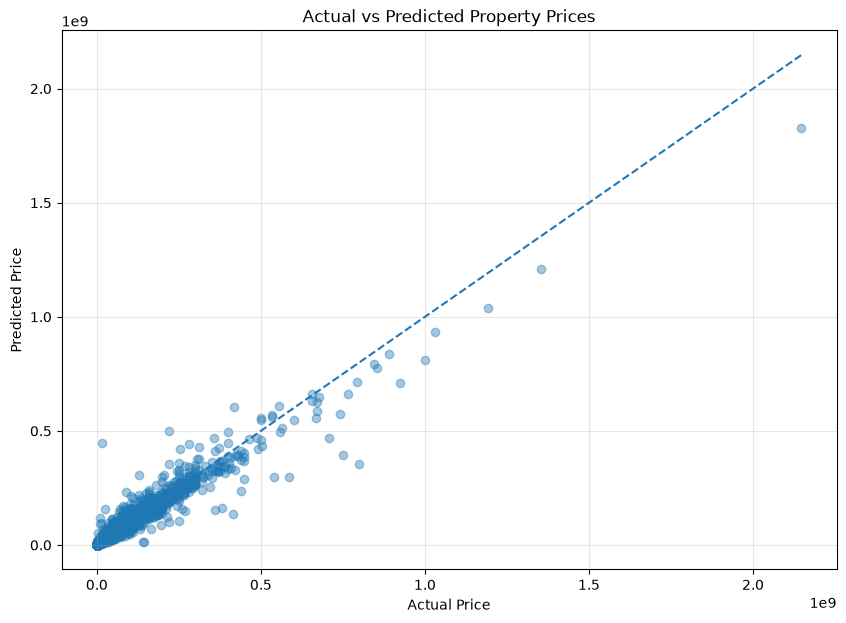

In [27]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    evaluation_df["actual_price"],
    evaluation_df["predicted_price"],
    alpha=0.4
)

min_price = min(
    evaluation_df["actual_price"].min(),
    evaluation_df["predicted_price"].min()
)

max_price = max(
    evaluation_df["actual_price"].max(),
    evaluation_df["predicted_price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Property Prices"
)

plt.grid(
    alpha=0.3
)

plt.show()

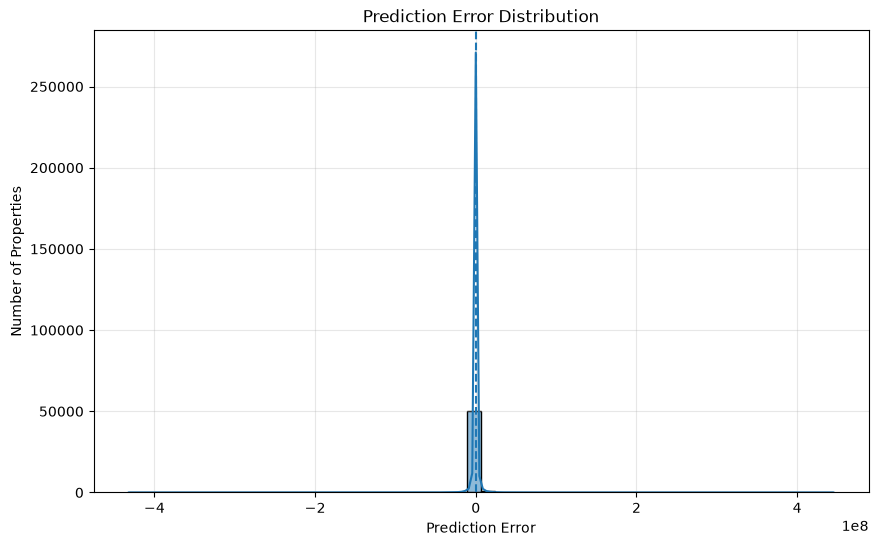

In [28]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    evaluation_df["error"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Number of Properties"
)

plt.title(
    "Prediction Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.show()

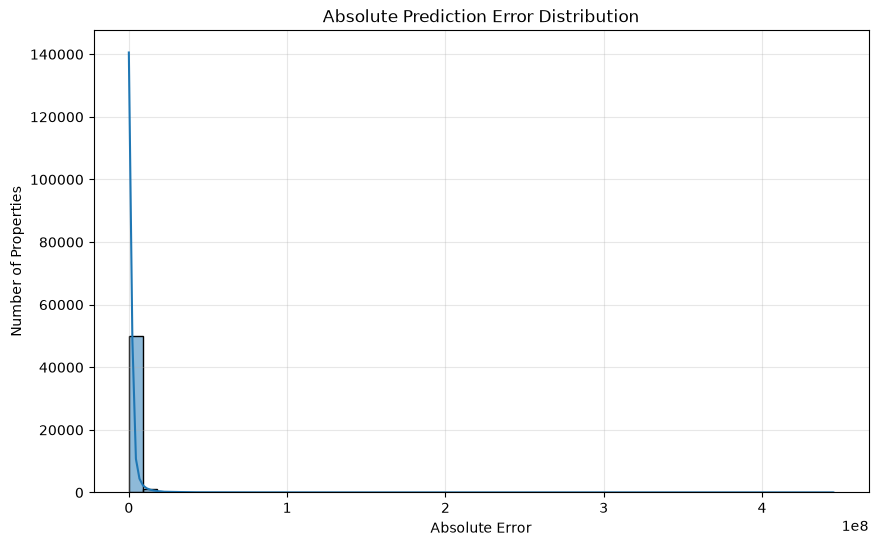

In [29]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    evaluation_df["absolute_error"],
    bins=50,
    kde=True
)

plt.xlabel(
    "Absolute Error"
)

plt.ylabel(
    "Number of Properties"
)

plt.title(
    "Absolute Prediction Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.show()

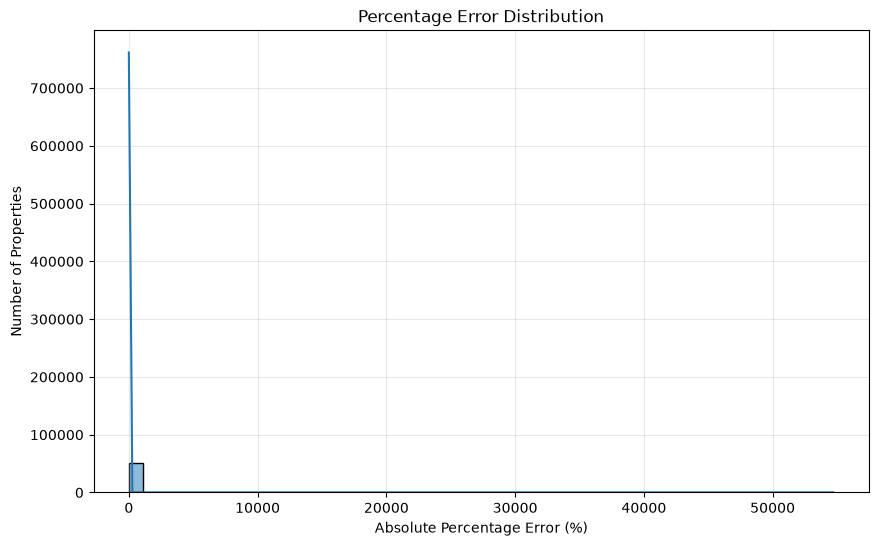

In [30]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    evaluation_df["percentage_error"].dropna(),
    bins=50,
    kde=True
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Number of Properties"
)

plt.title(
    "Percentage Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [31]:
error_statistics = evaluation_df[
    [
        "error",
        "absolute_error",
        "percentage_error"
    ]
].describe()

display(
    error_statistics
)

,error,absolute_error,percentage_error
count,5.176700e+04,5.176700e+04,51767.000000
mean,-8.080641e+04,1.817314e+06,9.387648
std,7.409380e+06,7.183505e+06,241.371207
min,-4.318288e+08,0.000000e+00,0.000000
25%,-5.997864e+05,1.699915e+05,1.843050
50%,-3.914198e+04,5.154067e+05,4.510773
75%,4.299085e+05,1.468593e+06,9.444931
max,4.451138e+08,4.451138e+08,54718.498562


In [32]:
evaluation_df["price_range"] = pd.cut(

    evaluation_df["actual_price"],

    bins=[
        0,
        5_000_000,
        10_000_000,
        20_000_000,
        50_000_000,
        np.inf
    ],

    labels=[
        "Below ₹50L",
        "₹50L - ₹1Cr",
        "₹1Cr - ₹2Cr",
        "₹2Cr - ₹5Cr",
        "Above ₹5Cr"
    ],

    include_lowest=True
)


price_range_performance = (
    evaluation_df
    .groupby(
        "price_range",
        observed=False
    )
    .agg(

        property_count=(
            "actual_price",
            "count"
        ),

        average_actual_price=(
            "actual_price",
            "mean"
        ),

        average_predicted_price=(
            "predicted_price",
            "mean"
        ),

        MAE=(
            "absolute_error",
            "mean"
        ),

        average_percentage_error=(
            "percentage_error",
            "mean"
        )

    )
    .reset_index()
)


display(
    price_range_performance
)

,price_range,property_count,average_actual_price,average_predicted_price,MAE,average_percentage_error
0,Below ₹50L,8679,3.500007e+06,3.711334e+06,3.328741e+05,17.003874
1,₹50L - ₹1Cr,13614,7.571939e+06,7.800477e+06,5.465656e+05,7.201932
2,₹1Cr - ₹2Cr,15065,1.472930e+07,1.510720e+07,1.149364e+06,7.821849
3,₹2Cr - ₹5Cr,10837,3.015428e+07,3.027933e+07,2.503157e+06,8.141543
4,Above ₹5Cr,3572,1.032044e+08,1.010178e+08,1.100366e+07,9.597035


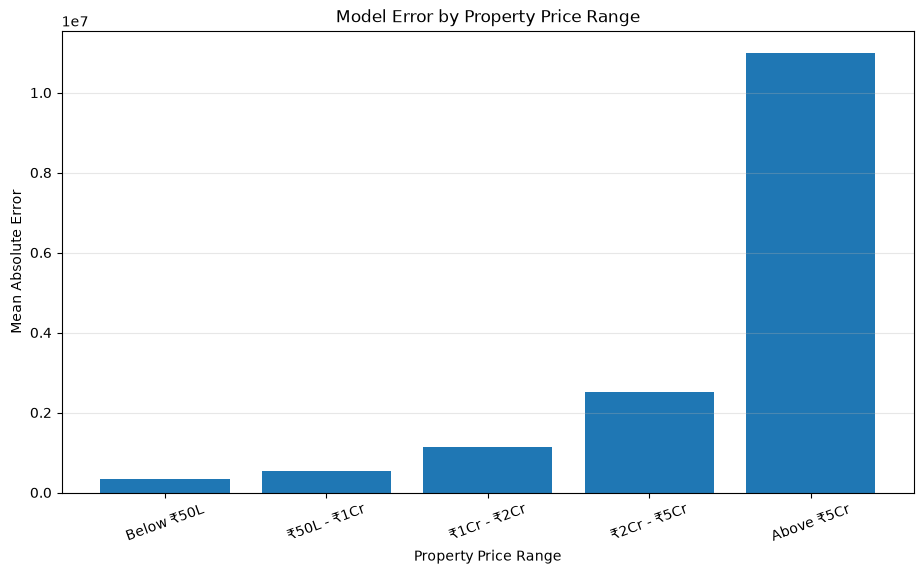

In [33]:
plt.figure(
    figsize=(11, 6)
)

plt.bar(
    price_range_performance["price_range"].astype(str),
    price_range_performance["MAE"]
)

plt.xlabel(
    "Property Price Range"
)

plt.ylabel(
    "Mean Absolute Error"
)

plt.title(
    "Model Error by Property Price Range"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [34]:
if "locality" not in evaluation_df.columns:

    raise ValueError(
        "❌ Locality column not found."
    )


locality_performance = (

    evaluation_df

    .groupby("locality")

    .agg(

        property_count=(
            "actual_price",
            "count"
        ),

        average_actual_price=(
            "actual_price",
            "mean"
        ),

        average_predicted_price=(
            "predicted_price",
            "mean"
        ),

        MAE=(
            "absolute_error",
            "mean"
        ),

        average_percentage_error=(
            "percentage_error",
            "mean"
        )

    )

    .reset_index()

)


locality_performance = (
    locality_performance
    .sort_values(
        "property_count",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Locality performance calculated."
)

display(
    locality_performance.head(20)
)

Locality performance calculated.


,locality,property_count,average_actual_price,average_predicted_price,MAE,average_percentage_error
0,Thane,5292,1.575273e+07,1.576839e+07,1.279443e+06,8.157598
1,Mira Road,3162,8.756489e+06,8.820194e+06,5.072112e+05,5.485675
2,Kandivali,2039,1.896827e+07,1.902520e+07,1.651340e+06,7.870504
3,Andheri,2039,3.217703e+07,3.283146e+07,3.208640e+06,10.014119
4,Kharghar,1904,1.394416e+07,1.393722e+07,1.340030e+06,9.830476
5,Dombivali,1872,6.019099e+06,6.042001e+06,3.689874e+05,6.761767
6,Kalyan,1738,6.488894e+06,6.507935e+06,4.941810e+05,8.243563
7,Borivali,1678,2.102899e+07,2.109490e+07,1.431306e+06,7.097082
8,Chembur,1591,2.372807e+07,2.385927e+07,1.918937e+06,8.420596
9,Malad,1522,1.938056e+07,1.965250e+07,1.440471e+06,7.663080


In [35]:
locality_error_analysis = (

    locality_performance

    .sort_values(
        "MAE",
        ascending=False
    )

    .reset_index(drop=True)

)


print(
    "Localities with highest average prediction error:"
)

display(
    locality_error_analysis.head(15)
)

Localities with highest average prediction error:


,locality,property_count,average_actual_price,average_predicted_price,MAE,average_percentage_error
0,Marine Drive,2,5.836834e+08,4.991178e+08,2.692236e+08,45.690206
1,Peddar Road,3,1.608333e+08,2.602487e+08,1.018007e+08,72.354353
2,Oshiwara Police Station Road,1,1.600000e+08,2.413512e+08,8.135121e+07,50.844508
3,Churchgate,5,5.068904e+08,4.917202e+08,8.133550e+07,20.937276
4,Uttan,3,1.833333e+07,8.949874e+07,7.211666e+07,453.576837
5,Juhu Scheme,11,1.952273e+08,1.504442e+08,5.638876e+07,21.459440
6,Napean Sea Road,1,3.768722e+08,3.258069e+08,5.106529e+07,13.549765
7,Malabar Hill,36,2.811580e+08,2.645042e+08,3.063384e+07,10.149267
8,Breach Candy,2,1.375000e+08,1.107067e+08,2.679332e+07,17.073434
9,Khar Danda,1,6.500000e+06,3.282274e+07,2.632274e+07,404.965289


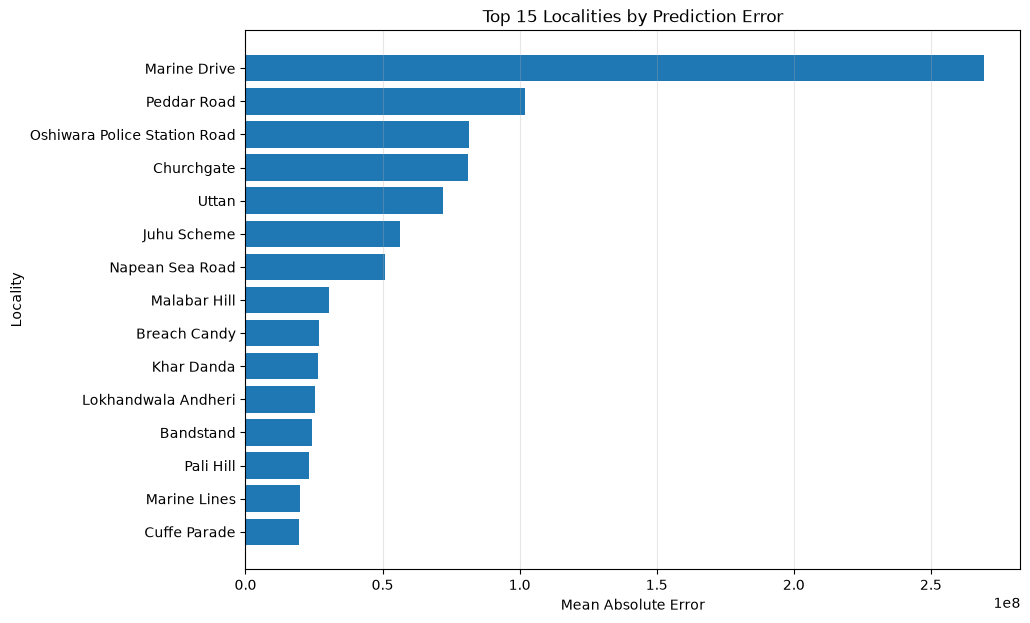

In [36]:
top_localities = (
    locality_error_analysis
    .head(15)
    .sort_values(
        "MAE",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_localities["locality"],
    top_localities["MAE"]
)

plt.xlabel(
    "Mean Absolute Error"
)

plt.ylabel(
    "Locality"
)

plt.title(
    "Top 15 Localities by Prediction Error"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [37]:
best_localities = (

    locality_performance[
        locality_performance["property_count"] >= 10
    ]

    .sort_values(
        "MAE",
        ascending=True
    )

    .reset_index(drop=True)

)


print(
    "Localities with lower average prediction error:"
)

display(
    best_localities.head(15)
)

Localities with lower average prediction error:


,locality,property_count,average_actual_price,average_predicted_price,MAE,average_percentage_error
0,Saphale,22,2.133564e+06,2.132691e+06,83966.928788,4.282872
1,Nere,17,2.122353e+06,2.138457e+06,94585.594143,4.235327
2,Kolhare,13,2.873243e+06,2.854220e+06,108434.768547,3.869840
3,Shilphata,21,5.013260e+06,5.028781e+06,164413.132720,3.173787
4,Nala Sopara,342,3.760641e+06,3.780344e+06,174875.932938,4.904134
5,Vevoor,21,2.142095e+06,2.207097e+06,199527.195450,11.026047
6,Ambernath,981,3.376406e+06,3.404316e+06,208498.677062,5.975974
7,Ambarnath,27,2.983333e+06,3.078950e+06,219408.528930,7.595555
8,Titwala,134,3.310103e+06,3.342140e+06,235976.298818,7.240651
9,Badlapur,471,2.978721e+06,3.008129e+06,238749.201987,6.966100


In [38]:
worst_predictions = (

    evaluation_df

    .sort_values(
        "absolute_error",
        ascending=False
    )

    .reset_index(drop=True)

)


print(
    "Properties with highest prediction error:"
)

display(

    worst_predictions[
        [
            "locality",
            "actual_price",
            "predicted_price",
            "error",
            "absolute_error",
            "percentage_error"
        ]
    ].head(20)

)


Properties with highest prediction error:


,locality,actual_price,predicted_price,error,absolute_error,percentage_error
0,Juhu Scheme,800000000,3.548862e+08,4.451138e+08,4.451138e+08,55.639221
1,Boisar,16005000,4.478338e+08,-4.318288e+08,4.318288e+08,2698.087153
2,Marine Drive,749181884,3.953926e+08,3.537893e+08,3.537893e+08,47.223413
3,Malabar Hill,2147483647,1.825561e+09,3.219229e+08,3.219229e+08,14.990704
4,Bandra Kurla Complex,585000000,2.987586e+08,2.862414e+08,2.862414e+08,48.930147
5,Bandra,220000000,5.008021e+08,-2.808021e+08,2.808021e+08,127.637296
6,Bandra,415800000,1.361045e+08,2.796955e+08,2.796955e+08,67.266841
7,Prabhadevi,540100000,2.995852e+08,2.405148e+08,2.405148e+08,44.531528
8,Kandivali,706730000,4.684042e+08,2.383258e+08,2.383258e+08,33.722329
9,Juhu,380000000,1.606352e+08,2.193648e+08,2.193648e+08,57.727568


In [39]:
best_predictions = (

    evaluation_df

    .sort_values(
        "absolute_error",
        ascending=True
    )

    .reset_index(drop=True)

)


print(
    "Properties with lowest prediction error:"
)

display(

    best_predictions[
        [
            "locality",
            "actual_price",
            "predicted_price",
            "error",
            "absolute_error",
            "percentage_error"
        ]
    ].head(20)

)

Properties with lowest prediction error:


,locality,actual_price,predicted_price,error,absolute_error,percentage_error
0,Goregaon,3200000,3.200000e+06,0.000000,0.000000,0.000000
1,Mulund,20000000,2.000000e+07,0.000000,0.000000,0.000000
2,Mulund,20000000,2.000000e+07,0.000000,0.000000,0.000000
3,Kanjurmarg,10055646,1.005564e+07,1.327111,1.327111,0.000013
4,Bhandup,9500000,9.500013e+06,-12.698413,12.698413,0.000134
5,Neral,2340000,2.340016e+06,-15.545238,15.545238,0.000664
6,Mira Road,8865000,8.865016e+06,-15.555556,15.555556,0.000175
7,Malad,15500000,1.550002e+07,-21.660000,21.660000,0.000140
8,Thane,10669529,1.066959e+07,-59.790000,59.790000,0.000560
9,Neral,2619500,2.619563e+06,-63.086667,63.086667,0.002408


In [40]:
def accuracy_category(error_percent):

    if error_percent <= 5:
        return "Very Accurate"

    elif error_percent <= 10:
        return "Accurate"

    elif error_percent <= 20:
        return "Moderate Error"

    elif error_percent <= 30:
        return "High Error"

    else:
        return "Very High Error"


evaluation_df["accuracy_category"] = (
    evaluation_df[
        "percentage_error"
    ].apply(
        accuracy_category
    )
)


accuracy_summary = (

    evaluation_df

    .groupby(
        "accuracy_category"
    )

    .size()

    .reset_index(
        name="property_count"
    )

)


accuracy_summary["percentage"] = (

    accuracy_summary[
        "property_count"
    ]

    /
    len(evaluation_df)

    * 100

)


display(
    accuracy_summary
)

,accuracy_category,property_count,percentage
0,Accurate,12034,23.246470
1,High Error,2212,4.272992
2,Moderate Error,7595,14.671509
3,Very Accurate,27733,53.572739
4,Very High Error,2193,4.236290


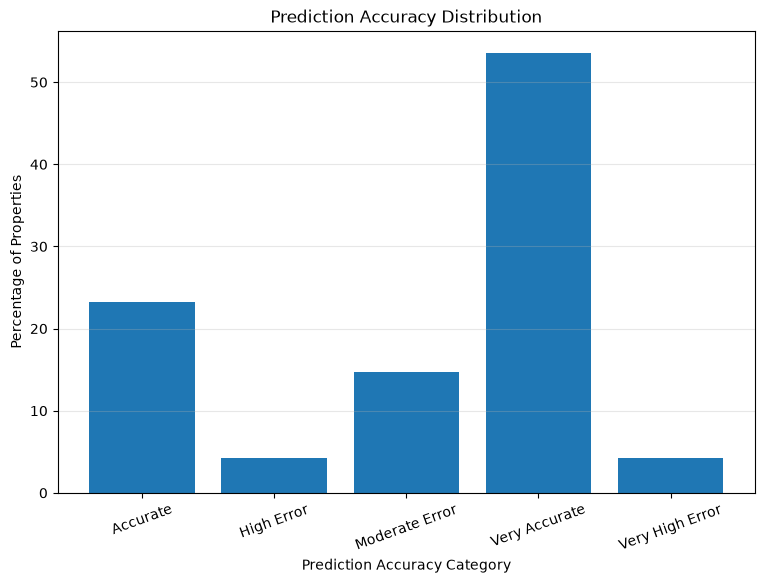

In [41]:
plt.figure(
    figsize=(9, 6)
)

plt.bar(
    accuracy_summary["accuracy_category"],
    accuracy_summary["percentage"]
)

plt.xlabel(
    "Prediction Accuracy Category"
)

plt.ylabel(
    "Percentage of Properties"
)

plt.title(
    "Prediction Accuracy Distribution"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [42]:
dashboard_metrics = {

    "total_properties": len(
        evaluation_df
    ),

    "r2_score": r2,

    "mae": mae,

    "rmse": rmse,

    "mape": mape,

    "average_actual_price": evaluation_df[
        "actual_price"
    ].mean(),

    "average_predicted_price": evaluation_df[
        "predicted_price"
    ].mean(),

    "median_actual_price": evaluation_df[
        "actual_price"
    ].median(),

    "median_predicted_price": evaluation_df[
        "predicted_price"
    ].median()

}


dashboard_metrics_df = pd.DataFrame(
    [dashboard_metrics]
)


display(
    dashboard_metrics_df
)

,total_properties,r2_score,mae,rmse,mape,average_actual_price,average_predicted_price,median_actual_price,median_predicted_price
0,51767,0.954333,1.817314e+06,7.409749e+06,9.387648,2.029837e+07,2.037918e+07,12000000.0,12247988.28


In [43]:
comparison_summary = pd.DataFrame({

    "Metric": [

        "Average Actual Price",

        "Average Predicted Price",

        "Median Actual Price",

        "Median Predicted Price",

        "Average Absolute Error",

        "Average Percentage Error"

    ],

    "Value": [

        evaluation_df[
            "actual_price"
        ].mean(),

        evaluation_df[
            "predicted_price"
        ].mean(),

        evaluation_df[
            "actual_price"
        ].median(),

        evaluation_df[
            "predicted_price"
        ].median(),

        evaluation_df[
            "absolute_error"
        ].mean(),

        evaluation_df[
            "percentage_error"
        ].mean()

    ]

})


display(
    comparison_summary
)

,Metric,Value
0,Average Actual Price,2.029837e+07
1,Average Predicted Price,2.037918e+07
2,Median Actual Price,1.200000e+07
3,Median Predicted Price,1.224799e+07
4,Average Absolute Error,1.817314e+06
5,Average Percentage Error,9.387648e+00


In [44]:
evaluation_path = os.path.join(
    OUTPUT_DIR,
    "model_evaluation_results.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False
)

print(
    "✅ Evaluation dataset exported:"
)

print(
    evaluation_path
)

✅ Evaluation dataset exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\model_evaluation_results.csv


In [45]:
performance_path = os.path.join(
    OUTPUT_DIR,
    "model_performance_summary.csv"
)

performance_summary.to_csv(
    performance_path,
    index=False
)

print(
    "✅ Performance summary exported:"
)

print(
    performance_path
)

✅ Performance summary exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\model_performance_summary.csv


In [46]:
locality_path = os.path.join(
    OUTPUT_DIR,
    "locality_model_performance.csv"
)

locality_performance.to_csv(
    locality_path,
    index=False
)

print(
    "✅ Locality performance exported:"
)

print(
    locality_path
)

✅ Locality performance exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\locality_model_performance.csv


In [47]:
price_range_path = os.path.join(
    OUTPUT_DIR,
    "price_range_model_performance.csv"
)

price_range_performance.to_csv(
    price_range_path,
    index=False
)

print(
    "✅ Price range performance exported:"
)

print(
    price_range_path
)

✅ Price range performance exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\price_range_model_performance.csv


In [48]:
dashboard_metrics_path = os.path.join(
    OUTPUT_DIR,
    "model_dashboard_metrics.csv"
)

dashboard_metrics_df.to_csv(
    dashboard_metrics_path,
    index=False
)

print(
    "✅ Dashboard metrics exported:"
)

print(
    dashboard_metrics_path
)


✅ Dashboard metrics exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\model_dashboard_metrics.csv


In [49]:
print("Checking generated output files...\n")

output_files = [
    evaluation_path,
    performance_path,
    locality_path,
    price_range_path,
    dashboard_metrics_path
]

for file in output_files:

    if os.path.exists(file):

        print(
            "✅",
            os.path.basename(file)
        )

    else:

        print(
            "❌",
            os.path.basename(file)
        )

Checking generated output files...

✅ model_evaluation_results.csv
✅ model_performance_summary.csv
✅ locality_model_performance.csv
✅ price_range_model_performance.csv
✅ model_dashboard_metrics.csv


In [50]:
print("=" * 60)
print("        MODEL PERFORMANCE REPORT")
print("=" * 60)

print(
    f"\nTotal Properties Evaluated : {len(evaluation_df):,}"
)

print(
    f"R² Score                   : {r2:.4f}"
)

print(
    f"MAE                        : ₹{mae:,.2f}"
)

print(
    f"RMSE                       : ₹{rmse:,.2f}"
)

print(
    f"MAPE                       : {mape:.2f}%"
)

print(
    f"\nAverage Actual Price      : "
    f"₹{evaluation_df['actual_price'].mean():,.2f}"
)

print(
    f"Average Predicted Price   : "
    f"₹{evaluation_df['predicted_price'].mean():,.2f}"
)

print(
    "\n" + "=" * 60
)

print(
    "✅ MODEL PERFORMANCE ANALYSIS COMPLETED"
)

print(
    "=" * 60
)

        MODEL PERFORMANCE REPORT

Total Properties Evaluated : 51,767
R² Score                   : 0.9543
MAE                        : ₹1,817,314.44
RMSE                       : ₹7,409,748.85
MAPE                       : 9.39%

Average Actual Price      : ₹20,298,373.61
Average Predicted Price   : ₹20,379,180.02

✅ MODEL PERFORMANCE ANALYSIS COMPLETED


In [51]:
final_dashboard = pd.DataFrame({

    "Metric": [
        "Total Properties",
        "R² Score",
        "MAE",
        "RMSE",
        "MAPE"
    ],

    "Result": [

        f"{len(evaluation_df):,}",

        f"{r2:.4f}",

        f"₹{mae:,.0f}",

        f"₹{rmse:,.0f}",

        f"{mape:.2f}%"

    ]

})


display(
    final_dashboard
)

,Metric,Result
0,Total Properties,"51,767"
1,R² Score,0.9543
2,MAE,"₹1,817,314"
3,RMSE,"₹7,409,749"
4,MAPE,9.39%


In [52]:
# Conclusion

The trained Mumbai House Price Prediction model was evaluated using the cleaned property dataset.

The evaluation includes:

- R² Score
- MAE
- RMSE
- MAPE
- Actual vs Predicted Price Analysis
- Residual Analysis
- Error Distribution
- Price Range Performance
- Locality-wise Performance
- Prediction Accuracy Categories

The generated CSV files can be reused by the Flask dashboard for displaying model performance.

SyntaxError: invalid character '²' (U+00B2) (307074384.py, line 7)